In [1]:
!pip install roboflow python-dotenv

import os
from dotenv import load_dotenv
from roboflow import Roboflow

load_dotenv()

DATASET_DIR = "dataset"

if not os.path.exists(os.path.join(DATASET_DIR, "data.yaml")):
    rf = Roboflow(api_key=os.environ["ROBOFLOW_API_KEY"])
    project = rf.workspace("khalid-abdullah-al-dosari").project("sixray-gzyn7")
    dataset = project.version(1).download("yolov8-obb", location=DATASET_DIR)
else:
    print(f"Dataset already present at ./{DATASET_DIR}, skipping download.")


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset already present at ./dataset, skipping download.


In [2]:
import os
import hashlib
import random
from collections import Counter, defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from PIL import Image

sns.set_theme(style="whitegrid")
random.seed(42)

with open(os.path.join(DATASET_DIR, "data.yaml")) as f:
    DATA_YAML = yaml.safe_load(f)

CLASS_NAMES = DATA_YAML["names"]
SPLITS = ["train", "valid", "test"]
print("Classes:", CLASS_NAMES)
print("Splits:", SPLITS)

Classes: {0: 'Gun', 1: 'Knife', 2: 'Pliers', 3: 'Scissors', 4: 'Wrench'}
Splits: ['train', 'valid', 'test']


## 1. Dataset Overview

Sixray is an X-ray baggage-screening dataset for prohibited-item detection (oriented bounding boxes). We confirm the source/version, the split sizes, and that every image has a matching label file (no orphans on either side).

In [3]:
overview_rows = []
image_index = {}  # split -> {stem: image_filename}
label_index = {}  # split -> {stem: label_filename}

for split in SPLITS:
    img_dir = os.path.join(DATASET_DIR, split, "images")
    lbl_dir = os.path.join(DATASET_DIR, split, "labels")

    images = {os.path.splitext(f)[0]: f for f in os.listdir(img_dir)}
    labels = {os.path.splitext(f)[0]: f for f in os.listdir(lbl_dir)}
    image_index[split] = images
    label_index[split] = labels

    images_without_labels = set(images) - set(labels)
    labels_without_images = set(labels) - set(images)

    overview_rows.append({
        "split": split,
        "n_images": len(images),
        "n_labels": len(labels),
        "images_without_labels": len(images_without_labels),
        "labels_without_images": len(labels_without_images),
    })

overview_df = pd.DataFrame(overview_rows).set_index("split")
overview_df.loc["total"] = overview_df.sum()
overview_df

,n_images,n_labels,images_without_labels,labels_without_images
split,,,,
train,5819,5819,0,0
valid,1662,1662,0,0
test,831,831,0,0
total,8312,8312,0,0


## 2. Parse Labels & Class Distribution

Every label file holds one line per object: `class x1 y1 x2 y2 x3 y3 x4 y4` (normalized OBB corner points). We parse all label files once into two DataFrames: `objects_df` (one row per object) and `images_df` (one row per image, with its object count). Both get reused for the rest of the notebook.

In [4]:
def polygon_area(pts):
    x, y = pts[:, 0], pts[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def obb_geometry(pts):
    center = pts.mean(axis=0)
    edge1 = pts[1] - pts[0]
    edge2 = pts[2] - pts[1]
    len1, len2 = float(np.linalg.norm(edge1)), float(np.linalg.norm(edge2))
    long_edge = edge1 if len1 >= len2 else edge2
    angle = float(np.degrees(np.arctan2(long_edge[1], long_edge[0])) % 180)
    long_side, short_side = max(len1, len2), max(min(len1, len2), 1e-9)
    return center[0], center[1], long_side, short_side, angle


object_rows = []
image_rows = []
malformed_lines = []

for split in SPLITS:
    lbl_dir = os.path.join(DATASET_DIR, split, "labels")
    for stem, lbl_fname in label_index[split].items():
        img_fname = image_index[split].get(stem)
        with open(os.path.join(lbl_dir, lbl_fname)) as f:
            lines = [ln.strip() for ln in f if ln.strip()]

        for line in lines:
            parts = line.split()
            if len(parts) != 9:
                malformed_lines.append((split, lbl_fname, line))
                continue
            cls_id = int(parts[0])
            coords = np.array(parts[1:], dtype=np.float32).reshape(4, 2)
            area = polygon_area(coords)
            out_of_bounds = bool(((coords < -1e-6) | (coords > 1 + 1e-6)).any())
            cx, cy, long_side, short_side, angle = obb_geometry(coords)
            object_rows.append({
                "split": split,
                "stem": stem,
                "class_id": cls_id,
                "class_name": CLASS_NAMES[cls_id],
                "area": area,
                "center_x": cx,
                "center_y": cy,
                "long_side": long_side,
                "short_side": short_side,
                "angle_deg": angle,
                "elongation": long_side / short_side,
                "degenerate": area < 1e-6 or out_of_bounds,
            })

        image_rows.append({
            "split": split,
            "stem": stem,
            "image_filename": img_fname,
            "n_objects": len(lines),
        })

objects_df = pd.DataFrame(object_rows)
images_df = pd.DataFrame(image_rows)

print(f"Malformed label lines: {len(malformed_lines)}")
print(f"Total annotated objects: {len(objects_df)}")
objects_df.head()

Malformed label lines: 0
Total annotated objects: 15668


,split,stem,class_id,class_name,area,center_x,center_y,long_side,short_side,angle_deg,elongation,degenerate
0,train,P00001_jpg.rf.4Ufi5TXEw8WEpqAvCEiI,1,Knife,0.170199,0.566813,0.519126,0.569750,0.298725,0.0,1.907274,False
1,train,P00001_jpg.rf.4Ufi5TXEw8WEpqAvCEiI,1,Knife,0.247145,0.477239,0.633880,0.510018,0.484582,90.0,1.052492,False
2,train,P00002_jpg.rf.HXEnqWHjuX5L8rueoOm0,1,Knife,0.290949,0.573034,0.710581,0.586767,0.495851,0.0,1.183353,False
3,train,P00002_jpg.rf.HXEnqWHjuX5L8rueoOm0,1,Knife,0.164020,0.506242,0.822614,0.530587,0.309129,0.0,1.716395,False
4,train,P00003_jpg.rf.Eph9xJ1sItEyKroXHCny,1,Knife,0.021973,0.859863,0.342187,0.300000,0.073242,90.0,4.096000,False


split,train,valid,test,total
class_name,,,,
Pliers,3680,1110,524,5314
Gun,3024,888,474,4386
Wrench,1943,530,306,2779
Knife,1473,442,169,2084
Scissors,779,206,120,1105


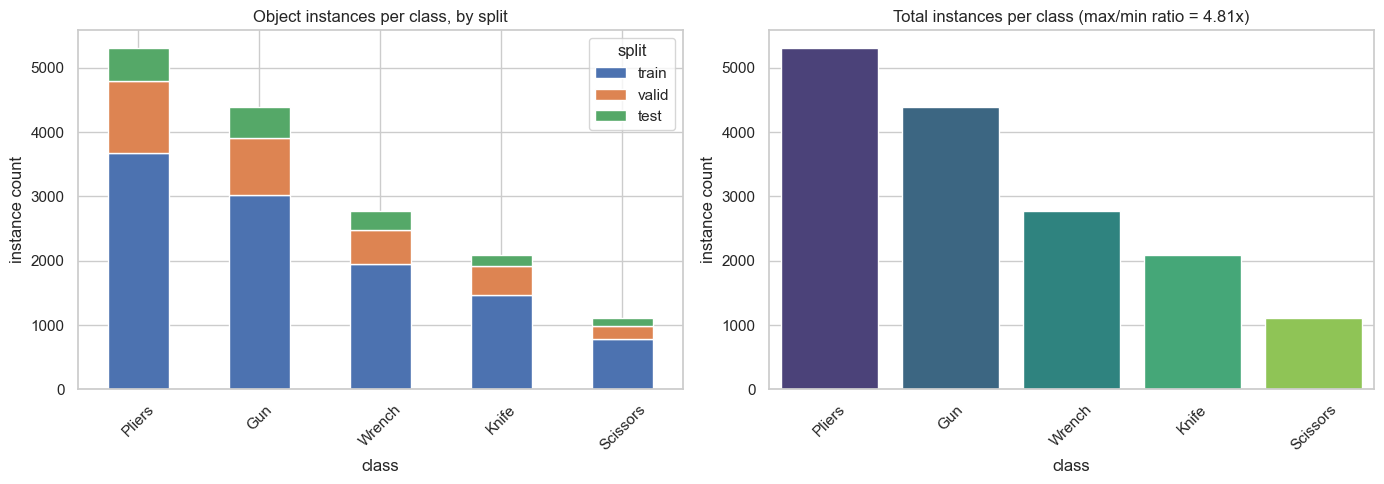

Class imbalance ratio (most frequent / least frequent): 4.81x


In [5]:
class_split_counts = (
    objects_df.groupby(["class_name", "split"]).size().unstack(fill_value=0)[SPLITS]
)
class_split_counts["total"] = class_split_counts.sum(axis=1)
class_split_counts = class_split_counts.sort_values("total", ascending=False)
display(class_split_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_split_counts[SPLITS].plot(kind="bar", stacked=True, ax=axes[0])
axes[0].set_title("Object instances per class, by split")
axes[0].set_xlabel("class")
axes[0].set_ylabel("instance count")
axes[0].tick_params(axis="x", rotation=45)

imbalance_ratio = class_split_counts["total"].max() / class_split_counts["total"].min()
sns.barplot(
    x=class_split_counts.index, y=class_split_counts["total"], ax=axes[1], hue=class_split_counts.index,
    palette="viridis", legend=False,
)
axes[1].set_title(f"Total instances per class (max/min ratio = {imbalance_ratio:.2f}x)")
axes[1].set_xlabel("class")
axes[1].set_ylabel("instance count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"Class imbalance ratio (most frequent / least frequent): {imbalance_ratio:.2f}x")

### 2a. Objects per Image

How many objects appear in a single scan, by split.

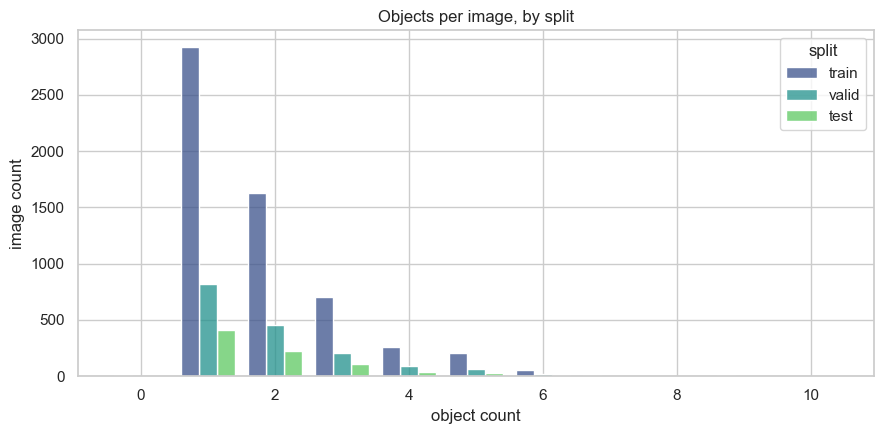

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(
    data=images_df, x="n_objects", hue="split", multiple="dodge",
    discrete=True, shrink=0.8, palette="viridis", ax=ax,
)
ax.set_title("Objects per image, by split")
ax.set_xlabel("object count")
ax.set_ylabel("image count")
plt.tight_layout()
plt.show()

### 2b. Object Size by Class

Object area as a share of the full image, by class.

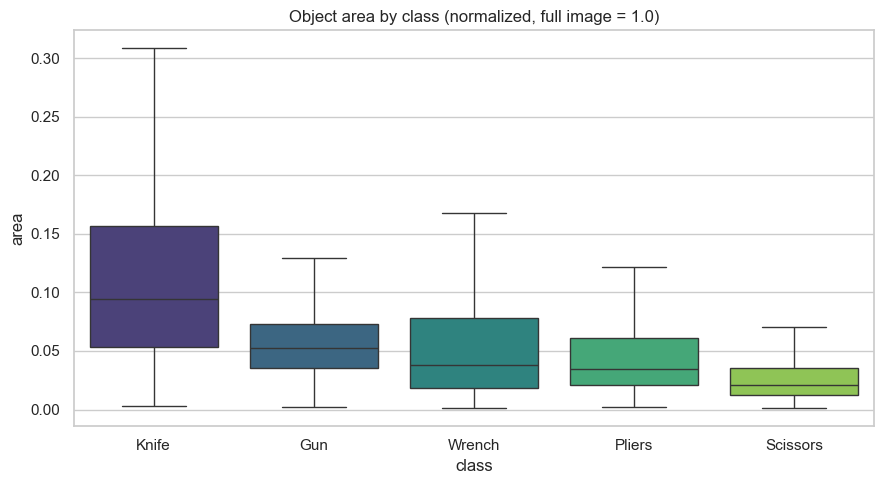

In [7]:
order = objects_df.groupby("class_name")["area"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=objects_df, x="class_name", y="area", order=order,
    hue="class_name", palette="viridis", legend=False, showfliers=False, ax=ax,
)
ax.set_title("Object area by class (normalized, full image = 1.0)")
ax.set_xlabel("class")
ax.set_ylabel("area")
plt.tight_layout()
plt.show()

### 2c. Orientation and Elongation

Rotation angle checks whether objects tumble freely in the bag. Elongation separates long thin classes from compact ones.

**Finding**: angles cluster almost entirely at 0 and 90 degrees, not spread across the full range. Annotations are effectively axis-aligned despite the OBB format, so the rotation-invariance advantage of OBB over a standard axis-aligned model may be smaller than expected on this dataset.

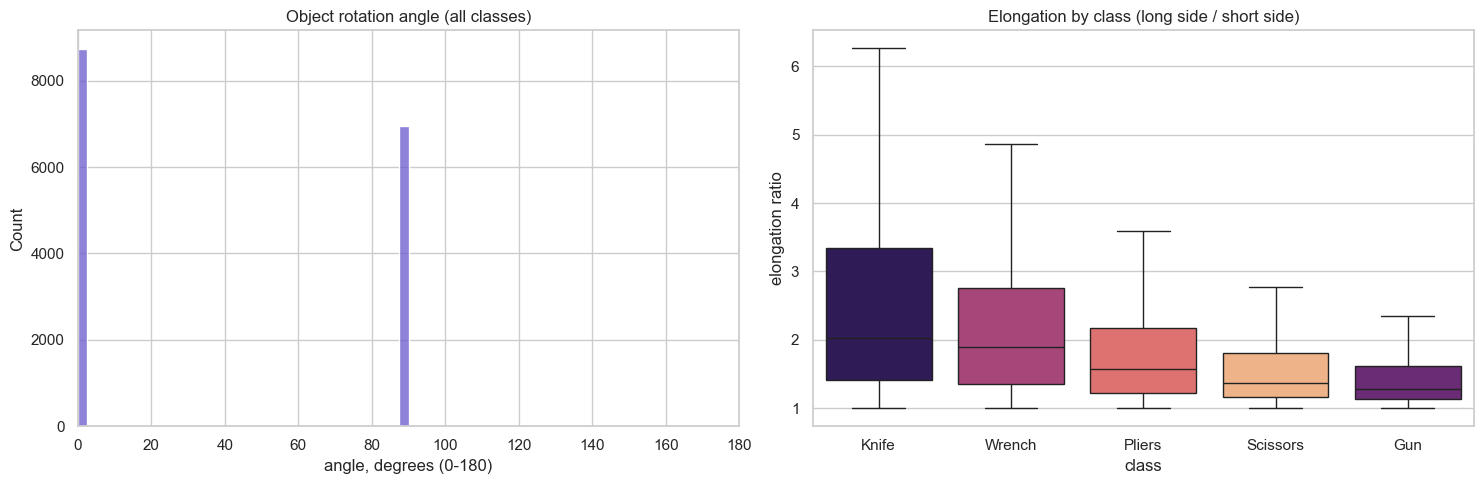

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(objects_df["angle_deg"], bins=36, ax=axes[0], color="slateblue")
axes[0].set_title("Object rotation angle (all classes)")
axes[0].set_xlabel("angle, degrees (0-180)")
axes[0].set_xlim(0, 180)

elong_order = objects_df.groupby("class_name")["elongation"].median().sort_values(ascending=False).index
sns.boxplot(
    data=objects_df, x="class_name", y="elongation", order=elong_order,
    hue="class_name", palette="magma", legend=False, showfliers=False, ax=axes[1],
)
axes[1].set_title("Elongation by class (long side / short side)")
axes[1].set_xlabel("class")
axes[1].set_ylabel("elongation ratio")

plt.tight_layout()
plt.show()

### 2d. Spatial Distribution

Where object centers fall within the frame.

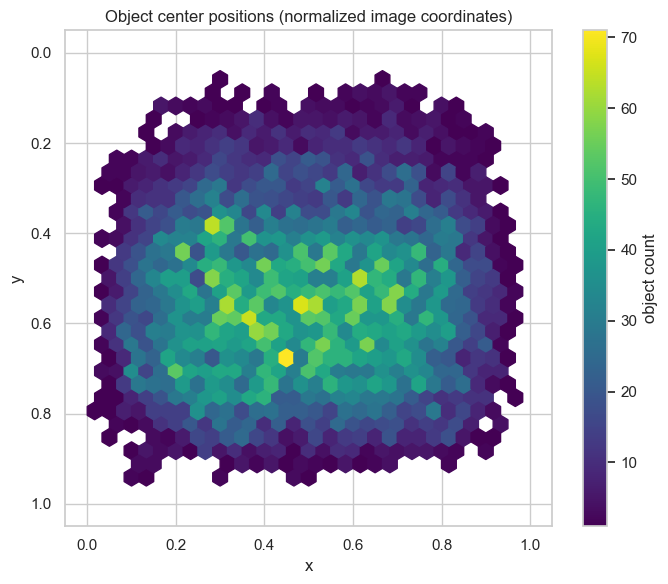

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
hb = ax.hexbin(
    objects_df["center_x"], objects_df["center_y"],
    gridsize=30, cmap="viridis", mincnt=1, extent=(0, 1, 0, 1),
)
ax.invert_yaxis()
ax.set_title("Object center positions (normalized image coordinates)")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(hb, ax=ax, label="object count")
plt.tight_layout()
plt.show()

### 2e. Class Co-occurrence

How often two classes appear together in the same image.

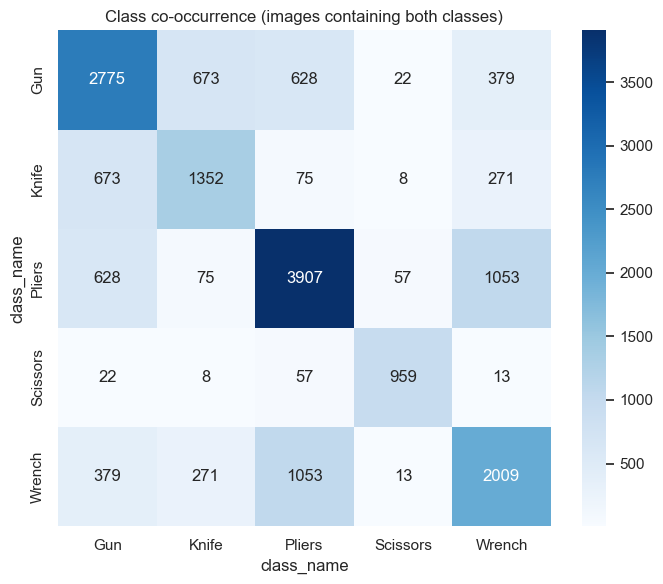

In [10]:
presence = (
    objects_df.groupby(["stem", "class_name"]).size().unstack(fill_value=0) > 0
).astype(int)
cooccurrence = presence.T.dot(presence)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cooccurrence, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Class co-occurrence (images containing both classes)")
plt.tight_layout()
plt.show()

## 3. Image Property Analysis

X-ray scanner captures rarely come out at a uniform resolution. We check the width/height/aspect-ratio spread to confirm resizing is needed before training (YOLO will letterbox to `imgsz` internally, but it's worth knowing how much variance we're feeding it).

In [11]:
size_rows = []
corrupt_images = []

for split in SPLITS:
    img_dir = os.path.join(DATASET_DIR, split, "images")
    for stem, fname in image_index[split].items():
        fpath = os.path.join(img_dir, fname)
        try:
            with Image.open(fpath) as im:
                w, h = im.size
        except Exception as e:
            corrupt_images.append((split, fname, str(e)))
            continue
        size_rows.append({"split": split, "stem": stem, "width": w, "height": h, "aspect_ratio": w / h})

sizes_df = pd.DataFrame(size_rows)
print(f"Corrupt/unreadable images: {len(corrupt_images)}")
sizes_df[["width", "height", "aspect_ratio"]].describe()

Corrupt/unreadable images: 0


,width,height,aspect_ratio
count,8312.000000,8312.000000,8312.000000
mean,657.120910,579.547883,1.154840
std,262.902117,159.475224,0.376594
min,151.000000,144.000000,0.255014
25%,473.000000,482.000000,0.880213
50%,623.000000,572.000000,1.130151
75%,812.000000,656.000000,1.405404
max,1773.000000,1691.000000,3.023622


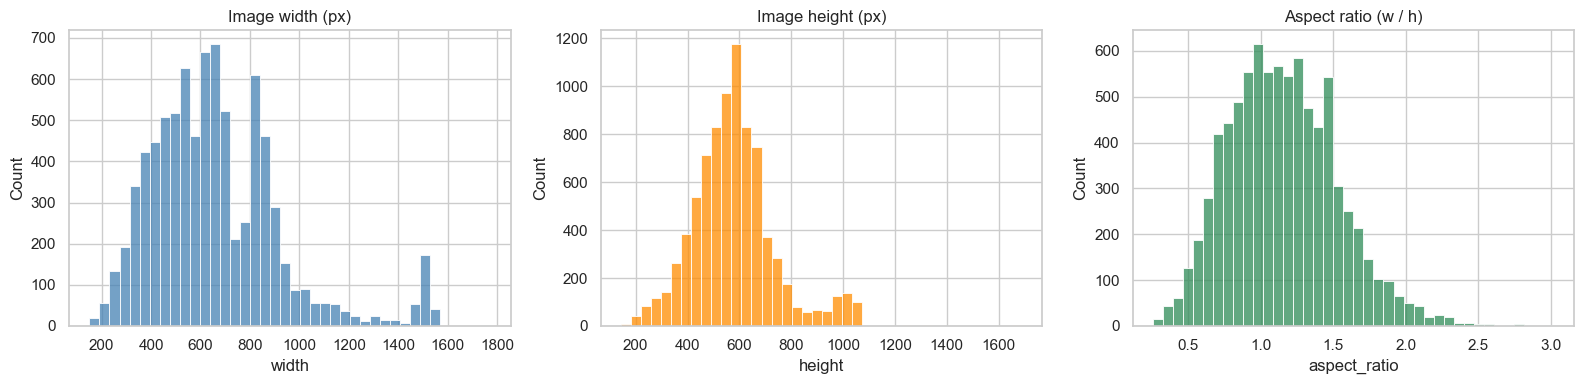

Unique resolutions: 7689 out of 8312 images
Most common resolutions:
width  height
1500   1035      54
888    1024      10
1024   640        9
928    1024       8
896    1024       6
dtype: int64


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(sizes_df["width"], bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("Image width (px)")
sns.histplot(sizes_df["height"], bins=40, ax=axes[1], color="darkorange")
axes[1].set_title("Image height (px)")
sns.histplot(sizes_df["aspect_ratio"], bins=40, ax=axes[2], color="seagreen")
axes[2].set_title("Aspect ratio (w / h)")
plt.tight_layout()
plt.show()

print(f"Unique resolutions: {sizes_df[['width', 'height']].drop_duplicates().shape[0]} out of {len(sizes_df)} images")
print("Most common resolutions:")
print(sizes_df.groupby(["width", "height"]).size().sort_values(ascending=False).head())

## 4. Sample Visualization (OBB Annotations)

Drawing the oriented bounding boxes on top of real samples is the fastest way to sanity-check that labels line up with objects and that the class names make sense.

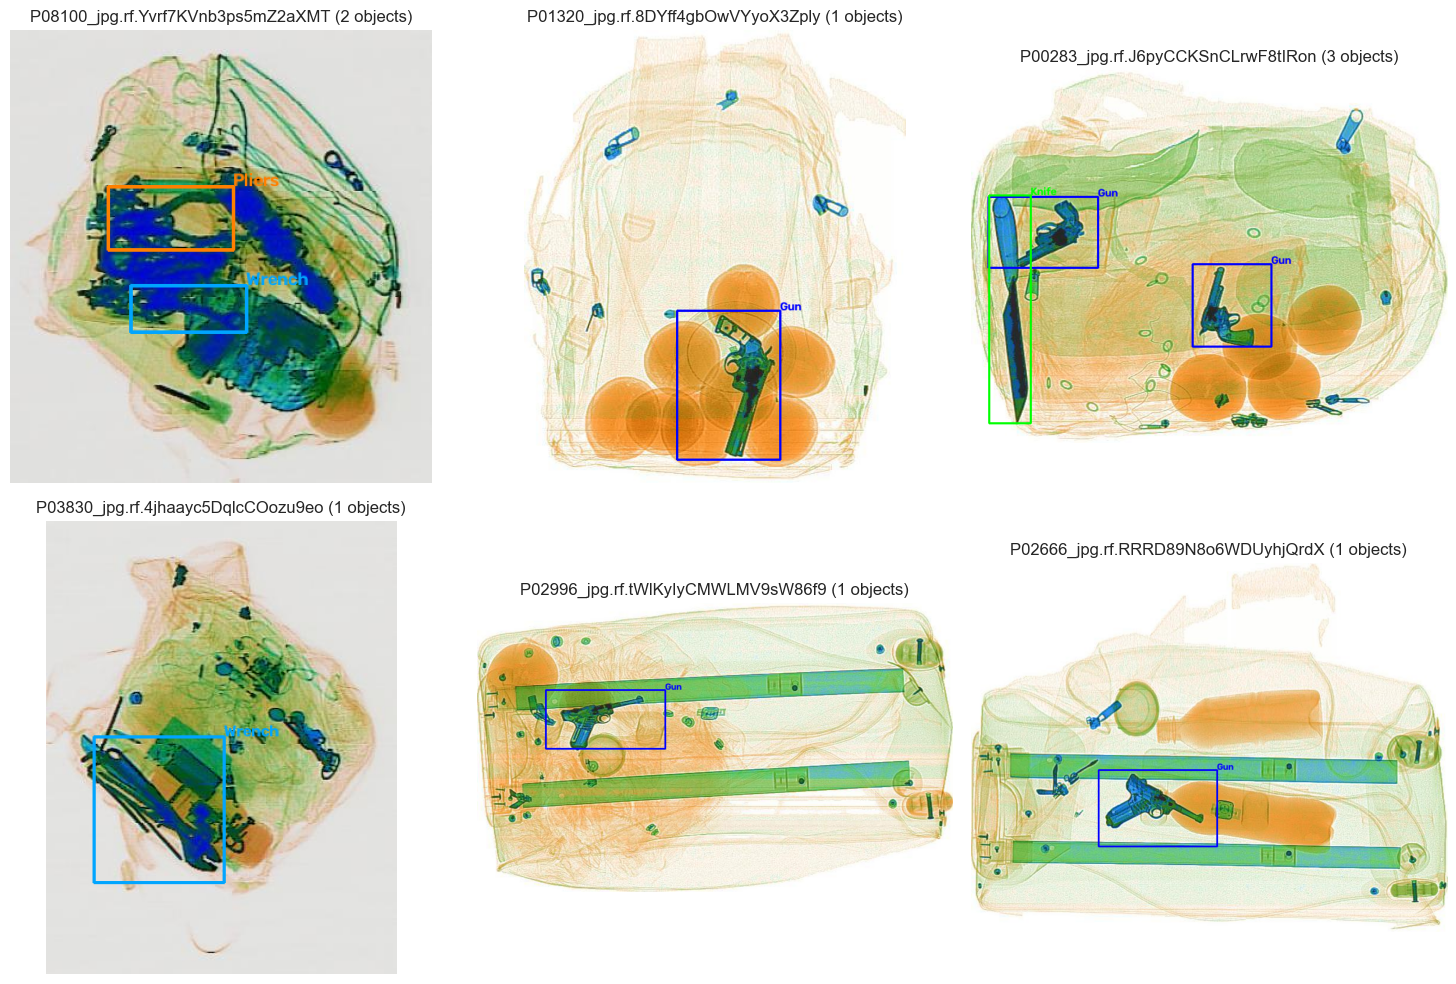

In [13]:
CLASS_COLORS = {
    "Gun": (255, 0, 0), "Knife": (0, 255, 0), "Pliers": (0, 128, 255),
    "Scissors": (255, 0, 255), "Wrench": (255, 165, 0),
}


def load_obb_labels(label_path):
    boxes = []
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls_id = int(parts[0])
            coords = np.array(parts[1:], dtype=np.float32).reshape(4, 2)
            boxes.append((CLASS_NAMES[cls_id], coords))
    return boxes


def draw_obb(image_bgr, boxes):
    image_bgr = image_bgr.copy()
    h, w = image_bgr.shape[:2]
    for class_name, coords in boxes:
        pts = (coords * [w, h]).astype(np.int32)
        color = CLASS_COLORS.get(class_name, (200, 200, 200))
        cv2.polylines(image_bgr, [pts], isClosed=True, color=color, thickness=2)
        cv2.putText(image_bgr, class_name, tuple(pts[0]), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    return image_bgr


sample_stems = random.sample(list(image_index["train"]), 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, stem in zip(axes.flat, sample_stems):
    img_path = os.path.join(DATASET_DIR, "train", "images", image_index["train"][stem])
    lbl_path = os.path.join(DATASET_DIR, "train", "labels", label_index["train"][stem])
    img = cv2.imread(img_path)
    boxes = load_obb_labels(lbl_path)
    drawn = cv2.cvtColor(draw_obb(img, boxes), cv2.COLOR_BGR2RGB)
    ax.imshow(drawn)
    ax.set_title(f"{stem} ({len(boxes)} objects)")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Data Quality Checks

Per the project brief: check quality, remove duplicates/unsuitable samples, and fix inaccurate labels. We check for exact-duplicate images (including **cross-split leakage**, which would silently inflate validation/test scores), empty-label ("background") images, and degenerate or out-of-bounds OBB polygons (already flagged while parsing in section 2).

In [14]:
# --- Exact-duplicate / cross-split leakage check (MD5 of raw image bytes) ---
hash_to_locations = defaultdict(list)
for split in SPLITS:
    img_dir = os.path.join(DATASET_DIR, split, "images")
    for stem, fname in image_index[split].items():
        with open(os.path.join(img_dir, fname), "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()
        hash_to_locations[file_hash].append((split, stem))

duplicate_groups = {h: locs for h, locs in hash_to_locations.items() if len(locs) > 1}
cross_split_leaks = {h: locs for h, locs in duplicate_groups.items() if len({s for s, _ in locs}) > 1}

# --- Empty-label ("background") images ---
empty_label_images = images_df[images_df["n_objects"] == 0]

# --- Degenerate / out-of-bounds boxes (flagged during parsing) ---
degenerate_boxes = objects_df[objects_df["degenerate"]]

print("=== Data Quality Report ===")
print(f"Corrupt/unreadable images:        {len(corrupt_images)}")
print(f"Malformed label lines:             {len(malformed_lines)}")
print(f"Exact-duplicate image groups:      {len(duplicate_groups)}")
print(f"  of which cross-split (leakage):  {len(cross_split_leaks)}")
print(f"Empty-label ('background') images: {len(empty_label_images)} ({empty_label_images.groupby('split').size().to_dict()})")
print(f"Degenerate/out-of-bounds boxes:    {len(degenerate_boxes)}")

print("\nObjects-per-image distribution:")
display(images_df.groupby("split")["n_objects"].describe())

=== Data Quality Report ===
Corrupt/unreadable images:        0
Malformed label lines:             0
Exact-duplicate image groups:      0
  of which cross-split (leakage):  0
Empty-label ('background') images: 17 ({'test': 2, 'train': 13, 'valid': 2})
Degenerate/out-of-bounds boxes:    0

Objects-per-image distribution:


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,831.0,1.916968,1.244395,0.0,1.0,2.0,2.0,9.0
train,5819.0,1.873002,1.195208,0.0,1.0,1.0,2.0,9.0
valid,1662.0,1.910951,1.216191,0.0,1.0,2.0,2.0,10.0


## 6. Class Balance Across Splits

Beyond overall class imbalance (section 2), we check that train/valid/test carry the same class *proportions*. A skewed split would make evaluation metrics unrepresentative.

split,train,valid,test
class_name,,,
Pliers,33.8%,34.9%,32.9%
Gun,27.7%,28.0%,29.8%
Wrench,17.8%,16.7%,19.2%
Knife,13.5%,13.9%,10.6%
Scissors,7.1%,6.5%,7.5%


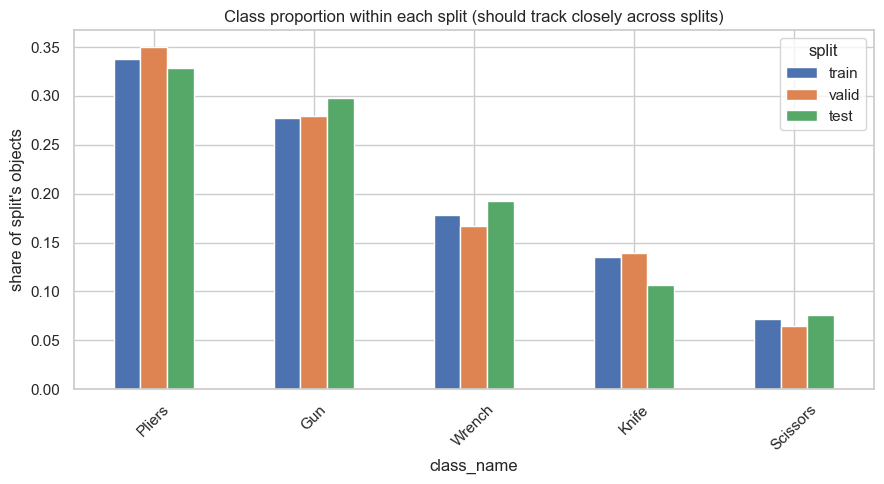

Largest cross-split proportion spread for a single class: 3.3%


In [15]:
class_proportions = class_split_counts[SPLITS].div(class_split_counts[SPLITS].sum(axis=0), axis=1)
display(class_proportions.style.format("{:.1%}"))

class_proportions.plot(kind="bar", figsize=(9, 5))
plt.title("Class proportion within each split (should track closely across splits)")
plt.ylabel("share of split's objects")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

max_spread = (class_proportions.max(axis=1) - class_proportions.min(axis=1)).max()
print(f"Largest cross-split proportion spread for a single class: {max_spread:.1%}")

## 7. Preprocessing: Data Cleaning

Acts on section 5's findings: drop corrupt images, drop exact-duplicate images (keeping one copy, prioritizing `train`), and drop degenerate/out-of-bounds object rows. `clean_stems` is the per-split set of image stems that pass all checks. Training should read through this list, not the raw folder listing.

In [16]:
corrupt_set = {(split, os.path.splitext(fname)[0]) for split, fname, _ in corrupt_images}

duplicate_drop_set = set()
for locs in duplicate_groups.values():
    # keep the copy from the highest-priority split (train > valid > test), drop the rest
    locs_sorted = sorted(locs, key=lambda sl: SPLITS.index(sl[0]))
    duplicate_drop_set.update(locs_sorted[1:])

clean_stems = {
    split: [stem for stem in image_index[split]
            if (split, stem) not in corrupt_set and (split, stem) not in duplicate_drop_set]
    for split in SPLITS
}
clean_stem_sets = {split: set(stems) for split, stems in clean_stems.items()}

clean_objects_df = objects_df[~objects_df["degenerate"]].copy()
clean_objects_df = clean_objects_df[
    clean_objects_df.apply(lambda r: r["stem"] in clean_stem_sets[r["split"]], axis=1)
]

for split in SPLITS:
    dropped = len(image_index[split]) - len(clean_stems[split])
    print(f"{split}: {len(clean_stems[split])} images kept, {dropped} dropped (corrupt/duplicate)")

dropped_objects = len(objects_df) - len(clean_objects_df)
print(f"\nObjects dropped as degenerate/out-of-bounds: {dropped_objects}")

train: 5819 images kept, 0 dropped (corrupt/duplicate)
valid: 1662 images kept, 0 dropped (corrupt/duplicate)
test: 831 images kept, 0 dropped (corrupt/duplicate)

Objects dropped as degenerate/out-of-bounds: 0


## 8. Preprocessing: Data Augmentation

Ultralytics' YOLOv8-OBB trainer already applies on-the-fly augmentation (mosaic, HSV jitter, flips, rotation/translation/scale/shear) during `model.train()`, so we don't need to pre-bake an augmented copy of the dataset to disk. What's demonstrated here instead:

1. An OBB-safe augmentation transform: rotation and horizontal flip applied consistently to both the image and the polygon corners. Arbitrary rotation angles are fine for OBB, unlike axis-aligned boxes.
2. A per-image **sample weight** for training, upweighting images with rarer classes (Scissors, Knife, roughly a 4-5x imbalance vs. Pliers/Gun) so training sees them more often.

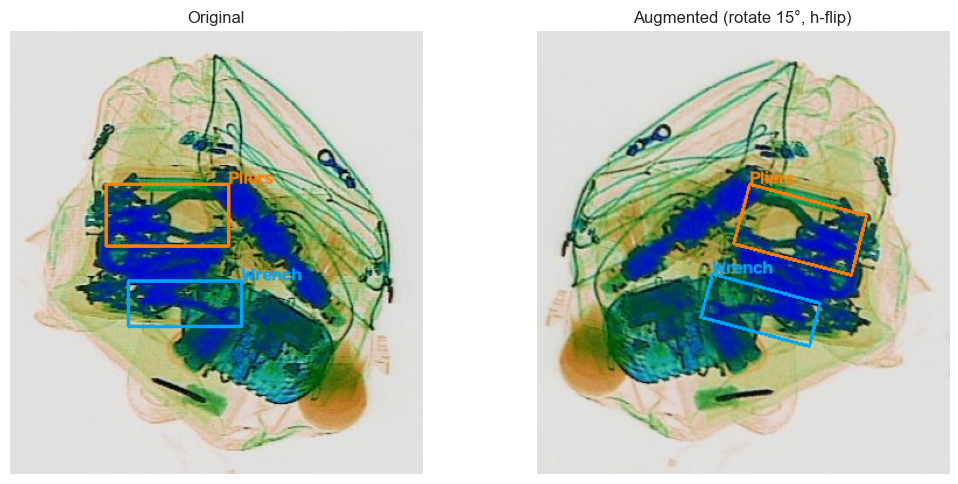

In [17]:
def augment_obb(image_bgr, boxes, angle_deg, flip_h):
    """Rotate (+ optional horizontal flip) an image and its OBB polygons together."""
    h, w = image_bgr.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle_deg, 1.0)
    rotated = cv2.warpAffine(image_bgr, M, (w, h), borderMode=cv2.BORDER_REFLECT)

    new_boxes = []
    for class_name, coords in boxes:
        pts = coords * [w, h]
        pts_h = np.hstack([pts, np.ones((4, 1))])
        rot_pts = (M @ pts_h.T).T
        if flip_h:
            rot_pts[:, 0] = w - rot_pts[:, 0]
        new_boxes.append((class_name, (rot_pts / [w, h]).astype(np.float32)))

    if flip_h:
        rotated = cv2.flip(rotated, 1)
    return rotated, new_boxes


demo_stem = sample_stems[0]
demo_img = cv2.imread(os.path.join(DATASET_DIR, "train", "images", image_index["train"][demo_stem]))
demo_boxes = load_obb_labels(os.path.join(DATASET_DIR, "train", "labels", label_index["train"][demo_stem]))
aug_img, aug_boxes = augment_obb(demo_img, demo_boxes, angle_deg=15, flip_h=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(cv2.cvtColor(draw_obb(demo_img, demo_boxes), cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(draw_obb(aug_img, aug_boxes), cv2.COLOR_BGR2RGB))
axes[1].set_title("Augmented (rotate 15°, h-flip)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [18]:
# Inverse-frequency class weight, then each training image's weight = max over the
# classes it contains (an image with a rare class gets sampled more often).
class_freq = clean_objects_df[clean_objects_df["split"] == "train"]["class_name"].value_counts()
inv_freq_weight = (class_freq.max() / class_freq).to_dict()

train_objects = clean_objects_df[clean_objects_df["split"] == "train"]
stem_to_weight = (
    train_objects.groupby("stem")["class_name"]
    .apply(lambda names: max(inv_freq_weight[n] for n in names))
)
# background (empty-label) train images keep a neutral weight of 1.0
sample_weights = pd.Series(1.0, index=clean_stems["train"])
sample_weights.update(stem_to_weight)
sample_weights.name = "sample_weight"

print("Inverse-frequency class weights (train split):")
print(pd.Series(inv_freq_weight).sort_values(ascending=False))
print(f"\nPer-image sample weights computed for {len(sample_weights)} training images")
sample_weights.sort_values(ascending=False).head()

Inverse-frequency class weights (train split):
Scissors    4.724005
Knife       2.498303
Wrench      1.893978
Gun         1.216931
Pliers      1.000000
dtype: float64

Per-image sample weights computed for 5819 training images


P04631_jpg.rf.ZvIpVzXFgq4pVg1lLpYK    4.724005
P04636_jpg.rf.GJRP25dBFQHI5GU7SXkg    4.724005
P04638_jpg.rf.u37i5vauZ643nrCWQlxB    4.724005
P04665_jpg.rf.Y3agLBy1zitCjKNQKRZG    4.724005
P08238_jpg.rf.i8h5IAH1Nk1nE35XuvDO    4.724005
Name: sample_weight, dtype: float64

### 8a. Before vs After Oversampling

Effective class instance counts once each image is duplicated by its rounded sample weight, the same scheme used at training time.

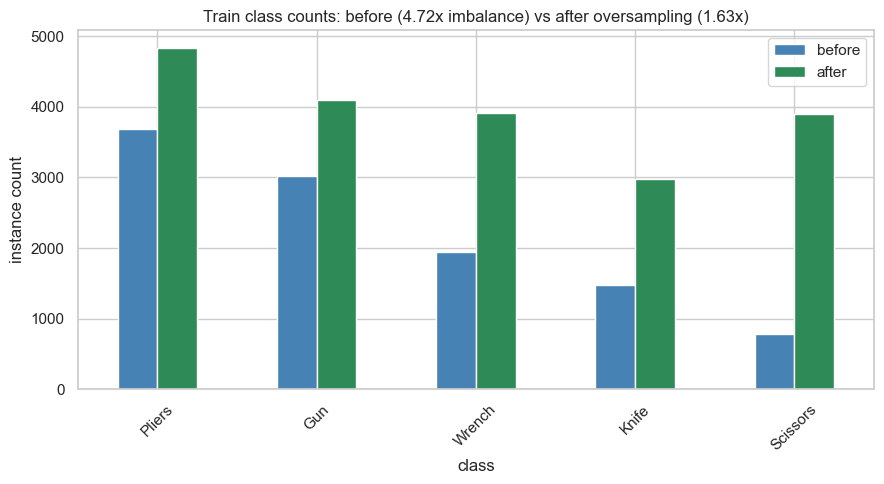

,before,after
class_name,,
Pliers,3680,4840
Gun,3024,4103
Wrench,1943,3910
Knife,1473,2976
Scissors,779,3895


Imbalance ratio before: 4.72x
Imbalance ratio after:  1.63x


In [19]:
train_clean = clean_objects_df[clean_objects_df["split"] == "train"]
before_counts = train_clean["class_name"].value_counts()

reps = sample_weights.round().clip(lower=1).astype(int)
per_image_counts = train_clean.groupby(["stem", "class_name"]).size().unstack(fill_value=0)
after_counts = per_image_counts.mul(reps.reindex(per_image_counts.index), axis=0).sum()

compare_df = pd.DataFrame({"before": before_counts, "after": after_counts}).reindex(before_counts.index)

before_ratio = compare_df["before"].max() / compare_df["before"].min()
after_ratio = compare_df["after"].max() / compare_df["after"].min()

compare_df.plot(kind="bar", figsize=(9, 5), color=["steelblue", "seagreen"])
plt.title(f"Train class counts: before ({before_ratio:.2f}x imbalance) vs after oversampling ({after_ratio:.2f}x)")
plt.xlabel("class")
plt.ylabel("instance count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(compare_df)
print(f"Imbalance ratio before: {before_ratio:.2f}x")
print(f"Imbalance ratio after:  {after_ratio:.2f}x")

## 9. Finalize & Export

Apply the section 7 cleaning decisions to disk. Flagged files move into a `_removed/` quarantine per split rather than being deleted, so the decision is reversible. Also export the training sample weights from section 8.

In [20]:
import shutil

to_remove = corrupt_set | duplicate_drop_set
for split, stem in to_remove:
    quarantine_img = os.path.join(DATASET_DIR, split, "_removed", "images")
    quarantine_lbl = os.path.join(DATASET_DIR, split, "_removed", "labels")
    os.makedirs(quarantine_img, exist_ok=True)
    os.makedirs(quarantine_lbl, exist_ok=True)

    img_fname = image_index[split].get(stem)
    lbl_fname = label_index[split].get(stem)
    if img_fname:
        src = os.path.join(DATASET_DIR, split, "images", img_fname)
        if os.path.exists(src):
            shutil.move(src, os.path.join(quarantine_img, img_fname))
    if lbl_fname:
        src = os.path.join(DATASET_DIR, split, "labels", lbl_fname)
        if os.path.exists(src):
            shutil.move(src, os.path.join(quarantine_lbl, lbl_fname))

print(f"Quarantined {len(to_remove)} image/label pairs (corrupt or duplicate).")

sample_weights.to_csv(os.path.join(DATASET_DIR, "train_sample_weights.csv"), header=True)
print(f"Saved training sample weights to {DATASET_DIR}/train_sample_weights.csv")

Quarantined 0 image/label pairs (corrupt or duplicate).
Saved training sample weights to dataset/train_sample_weights.csv


## 10. Readiness Checklist

Maps back to the capstone brief's data-processing requirements (section 6 of the project guide).

In [21]:
checklist = [
    ("Data source documented", "Roboflow project 'sixray-gzyn7' (Sixray X-ray baggage screening), v1"),
    ("Image/class counts described", f"{len(images_df)} images, {len(CLASS_NAMES)} classes: {list(CLASS_NAMES.values())}"),
    ("Quality checked, duplicates removed", f"{len(corrupt_images)} corrupt, {len(duplicate_groups)} duplicate groups ({len(cross_split_leaks)} cross-split) -> quarantined"),
    ("Labels validated", f"{len(malformed_lines)} malformed lines, {len(degenerate_boxes)} degenerate/out-of-bounds boxes -> excluded"),
    ("Train/valid/test split confirmed", f"train={len(clean_stems['train'])}, valid={len(clean_stems['valid'])}, test={len(clean_stems['test'])}, no cross-split leakage"),
    ("Data augmentation strategy defined", "OBB-safe rotate+flip transform demoed; on-the-fly aug via YOLOv8-OBB trainer at train time"),
    ("Class balance examined", f"imbalance ratio {imbalance_ratio:.2f}x (max/min class) -> per-image sample weights exported"),
    ("Samples visualized", "6 annotated samples rendered with OBB polygons in section 4"),
]

checklist_df = pd.DataFrame(checklist, columns=["Requirement", "Status / Evidence"])
checklist_df

,Requirement,Status / Evidence
0,Data source documented,Roboflow project 'sixray-gzyn7' (Sixray X-ray ...
1,Image/class counts described,"8312 images, 5 classes: ['Gun', 'Knife', 'Plie..."
2,"Quality checked, duplicates removed","0 corrupt, 0 duplicate groups (0 cross-split) ..."
3,Labels validated,"0 malformed lines, 0 degenerate/out-of-bounds ..."
4,Train/valid/test split confirmed,"train=5819, valid=1662, test=831, no cross-spl..."
5,Data augmentation strategy defined,OBB-safe rotate+flip transform demoed; on-the-...
6,Class balance examined,imbalance ratio 4.81x (max/min class) -> per-i...
7,Samples visualized,6 annotated samples rendered with OBB polygons...
